In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
from google.colab import files
import zipfile
import io
import pandas as pd

uploaded = files.upload()

for fn in uploaded.keys():
  if fn.endswith('.zip'):
    with zipfile.ZipFile(io.BytesIO(uploaded[fn]), 'r') as z:
      z.extractall('/content/')
    # Assuming the CSV is directly inside the zip and named 'BNB_USD_daily_data.csv'
    # You might need to adjust the filename if it's different
    df = pd.read_csv('/content/BNB_USD_daily_data.csv')
  else:
    # Handle single CSV file upload directly
    df = pd.read_csv(io.BytesIO(uploaded[fn]))

# Preview data
df.head()

Saving archive (3).zip to archive (3) (1).zip


,Date,Open,High,Low,Close,Adj Close,Volume
0,2017-11-09,2.05314,2.17423,1.89394,1.99077,1.99077,19192200
1,2017-11-10,2.00773,2.06947,1.64478,1.79684,1.79684,11155000
2,2017-11-11,1.78628,1.91775,1.61429,1.67047,1.67047,8178150
3,2017-11-12,1.66889,1.67280,1.46256,1.51969,1.51969,15298700
4,2017-11-13,1.52601,1.73502,1.51760,1.68662,1.68662,12238800


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2496 entries, 0 to 2495
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2496 non-null   object 
 1   Open       2496 non-null   float64
 2   High       2496 non-null   float64
 3   Low        2496 non-null   float64
 4   Close      2496 non-null   float64
 5   Adj Close  2496 non-null   float64
 6   Volume     2496 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 136.6+ KB


,Open,High,Low,Close,Adj Close,Volume
count,2496.000000,2496.000000,2496.000000,2496.000000,2496.000000,2.496000e+03
mean,200.659028,206.056428,194.862148,200.835476,200.835476,9.912548e+08
std,197.635450,202.848770,191.818301,197.642034,197.642034,1.312163e+09
min,1.511360,1.582660,1.462560,1.510360,1.510360,9.284000e+03
25%,16.316653,16.714783,15.889089,16.330410,16.330410,2.007160e+08
50%,215.021477,217.985298,212.038757,215.105324,215.105324,4.795286e+08
75%,323.150475,331.422844,315.119118,323.133606,323.133606,1.459083e+09
max,710.460388,720.672607,692.994751,710.464050,710.464050,1.798295e+10


In [ ]:
# Convert Date column to datetime if exists
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

# Drop null values
df.dropna(inplace=True)


In [ ]:
target_col = 'Close'

X = df.drop(columns=[target_col, 'Date'], errors='ignore')
y = df[target_col]


In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 1.5726531188420267e-13
MSE: 2.8693173413440087e-26
RMSE: 1.693905942295501e-13
R2 Score: 1.0


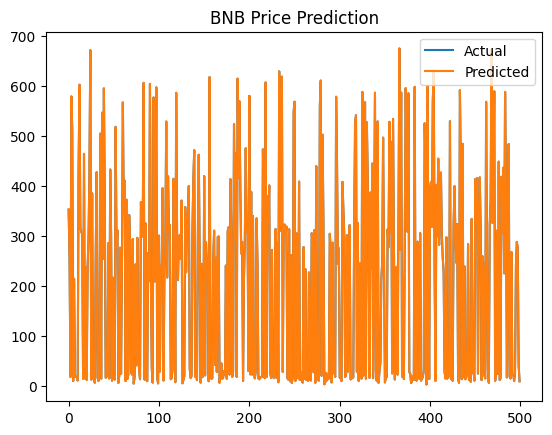

In [ ]:
plt.figure()
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title('BNB Price Prediction')
plt.show()


In [ ]:
import joblib

joblib.dump(model, "bnb_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
import os

# Create project folders
os.makedirs("bnb_project/api", exist_ok=True)
os.makedirs("bnb_project/templates", exist_ok=True)
os.makedirs("bnb_project/static", exist_ok=True)

print("Folders created successfully ✅")

Folders created successfully ✅


In [ ]:
import joblib

joblib.dump(model, "bnb_project/bnb_model.pkl")
joblib.dump(scaler, "bnb_project/scaler.pkl")

print("Model and scaler saved ✅")

Model and scaler saved ✅


In [ ]:
backend_code = '''
from flask import Flask, request, render_template
import numpy as np
import joblib

app = Flask(__name__, template_folder="../templates", static_folder="../static")

model = joblib.load("bnb_model.pkl")
scaler = joblib.load("scaler.pkl")

@app.route("/", methods=["GET", "POST"])
def home():
    prediction = None

    if request.method == "POST":
        open_price = float(request.form["open"])
        high_price = float(request.form["high"])
        low_price = float(request.form["low"])
        volume = float(request.form["volume"])

        features = np.array([[open_price, high_price, low_price, volume]])
        features_scaled = scaler.transform(features)
        prediction = model.predict(features_scaled)[0]

    return render_template("index.html", prediction=prediction)

if __name__ == "__main__":
    app.run()
'''

with open("bnb_project/api/index.py", "w") as f:
    f.write(backend_code)

print("Backend file created ✅")

Backend file created ✅


In [ ]:
html_code = '''
<!DOCTYPE html>
<html>
<head>
    <title>BNB Price Predictor</title>
    <link rel="stylesheet" href="/static/style.css">
</head>
<body>
<div class="container">
    <h1>BNB Price Prediction</h1>

    <form method="POST">
        <input type="number" step="any" name="open" placeholder="Open Price" required>
        <input type="number" step="any" name="high" placeholder="High Price" required>
        <input type="number" step="any" name="low" placeholder="Low Price" required>
        <input type="number" step="any" name="volume" placeholder="Volume" required>
        <button type="submit">Predict Close Price</button>
    </form>

    {% if prediction %}
    <div class="result">
        Predicted Close Price: {{ prediction }}
    </div>
    {% endif %}
</div>
</body>
</html>
'''

with open("bnb_project/templates/index.html", "w") as f:
    f.write(html_code)

print("HTML file created ✅")

HTML file created ✅


In [1]:
css_code = '''
body {
    font-family: Arial;
    background: linear-gradient(135deg, #1e3c72, #2a5298);
    display: flex;
    justify-content: center;
    align-items: center;
    height: 100vh;
}
.container {
    background: white;
    padding: 40px;
    border-radius: 12px;
    width: 350px;
    text-align: center;
}
input {
    width: 100%;
    padding: 10px;
    margin: 10px 0;
}
button {
    padding: 10px;
    width: 100%;
    background: #2a5298;
    color: white;
    border: none;
}
.result {
    margin-top: 20px;
    font-weight: bold;
    color: green;
}
'''

with open("bnb_project/static/style.css", "w") as f:
    f.write(css_code)

print("CSS file created ✅")

FileNotFoundError: [Errno 2] No such file or directory: 'bnb_project/static/style.css'

In [ ]:
requirements = '''
flask
numpy
joblib
scikit-learn
'''

with open("bnb_project/requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created ✅")

requirements.txt created ✅


In [ ]:
vercel_config = '''
{
  "version": 2,
  "builds": [
    { "src": "api/index.py", "use": "@vercel/python" }
  ],
  "routes": [
    { "src": "/(.*)", "dest": "api/index.py" }
  ]
}
'''

with open("bnb_project/vercel.json", "w") as f:
    f.write(vercel_config)

print("vercel.json created ✅")

vercel.json created ✅


In [ ]:
import shutil

shutil.make_archive("bnb_project", 'zip', "bnb_project")
print("Project zipped ✅")

Project zipped ✅
